In [2]:
!pip install shap
!pip install polars

  Using cached shap-0.51.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.51.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.1 MB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 197.9 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]2/3 [shap]]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not instal

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import math
import pandas as pd
import polars as pl
import numpy as np
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import time

In [4]:
import joblib
import boto3
import tempfile
import logging

In [5]:
def save_model_to_s3(model, bucket_name, object_key):
    s3_client = boto3.client('s3')
    try:
        with tempfile.TemporaryFile() as fp:
            joblib.dump(model, fp)
            fp.seek(0) # Rewind the file pointer to the beginning
            s3_client.put_object(Body=fp.read(), Bucket=bucket_name, Key=object_key)
            logging.info(f'{object_key} saved to s3 bucket {bucket_name}')
    except Exception as e:
        logging.exception(e)
        raise

In [6]:
pl.Config.set_tbl_rows(50)

polars.config.Config

In [7]:
# Read aggregated data from S3
df = pl.read_parquet("s3://msds-26.2-data/clean/combined_recovery_data_aggregated_with_new_features.parquet")

In [8]:
# Drop all week where lag features is null
df = df.drop_nulls(subset=['units_recovered_prob_mean_12'])

In [9]:
df.describe()

statistic,hashed_fc,gl_product_group,start,end,week_date,year,month,week,num_records,units_RETAIL,units_FBA,units_hazmat,units_food,units_non_food,units_pet_food,units_total,cogs_total,weight_total,country,country_state,zip_code,site_type,site_category,units_recovered,avg_cogs_per_unit,avg_weight_per_unit,cogs_per_unit_weight,share_food,share_non_food,share_pet_food,share_RETAIL,share_FBA,share_hazmat,units_recovered_prob,site_units_total_week,site_weight_total_week,…,site_units_total_week_lag_2,site_units_total_week_lag_4,site_units_total_week_lag_12,site_units_total_week_mean_4,site_units_total_week_mean_12,site_weight_total_week_lag_1,site_weight_total_week_lag_2,site_weight_total_week_lag_4,site_weight_total_week_lag_12,site_weight_total_week_mean_4,site_weight_total_week_mean_12,site_units_recovered_week_lag_1,site_units_recovered_week_lag_2,site_units_recovered_week_lag_4,site_units_recovered_week_lag_12,site_units_recovered_week_mean_4,site_units_recovered_week_mean_12,site_units_share_week_lag_1,site_units_share_week_lag_2,site_units_share_week_lag_4,site_units_share_week_lag_12,site_units_share_week_mean_4,site_units_share_week_mean_12,site_weight_share_week_lag_1,site_weight_share_week_lag_2,site_weight_share_week_lag_4,site_weight_share_week_lag_12,site_weight_share_week_mean_4,site_weight_share_week_mean_12,site_recovered_share_week_lag_1,site_recovered_share_week_lag_2,site_recovered_share_week_lag_4,site_recovered_share_week_lag_12,site_recovered_share_week_mean_4,site_recovered_share_week_mean_12,week_sin,week_cos
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""8008839""",8.008839e6,"""8008839""","""8008839""","""8008839""",8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,"""8008839""","""5042142""","""5039203""","""5042142""","""5042142""",8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,…,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6,8.008839e6
"""null_count""","""0""",0.0,"""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""2966697""","""2969636""","""2966697""","""2966697""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,265.32775,"""2022-06-20 15:32:57.861060""","""2025-10-10 02:00:08.174668""","""2024-03-25 19:38:38.241183""",2023.720722,6.82257,27.6394,6.64546,1435.935717,2613.844406,299.278694,273.677361,3716.680042,59.422719,4049.780123,31653.960234,4.3885e6,null,null,null,null,null,202.037473,27.346202,3714.403646,0.053465,0.047572,0.947209,0.005219,0.642169,0.357831,0.114814,0.093708,371064.115263,3.2273e8,…,353698.685788,349812.578352,341769.056876,352873.88728,347255.308627,3.0928e8,3.0708e8,3.0365e8,2.9611e8,3.0635e8,3.0118e8,17036.212353,17017.510201,17006.369809,16810.513946,17018.465275,16949.107397,0.151825,0.149629,0.146991,0.141496,0.149107,0.145277,0.152974,0.150795,0.148169,0.142591,0.150274,0.14643,0.021775,0.021599,0.021374,0.020558,0.021547,0.021121,-0.042204,-0.022468
"""std""",null,170.344267,null,null,null,1.072977,3.378798,14.771338,11.781935,6453.95332,12556.945938,1978.600751,4152.264759,16641

<Axes: xlabel='units_recovered_prob', ylabel='Count'>

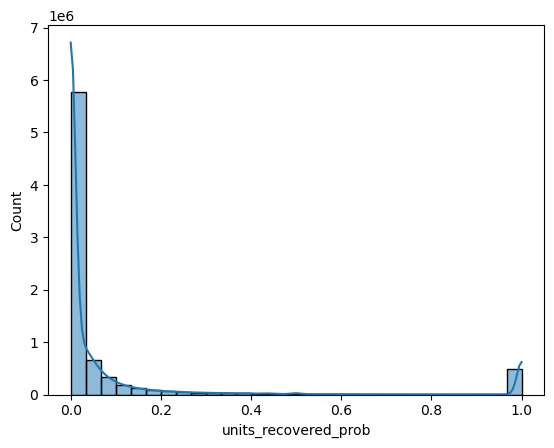

In [10]:
sns.histplot(df, x='units_recovered_prob', kde=True, bins=30)

In [8]:
df.group_by('year').agg(pl.mean('units_recovered_prob').alias('mean_recovery_prop'),
                        pl.std('units_recovered_prob').alias('std_recovery_prop')).sort(by='year')

year,mean_recovery_prop,std_recovery_prop
i64,f64,f64
2022,0.106892,0.260821
2023,0.097148,0.253644
2024,0.088848,0.240724
2025,0.088074,0.238007


In [9]:
df.group_by(['site_type']).agg(pl.mean('units_recovered_prob').alias('mean_recovery_prop'),
                        pl.std('units_recovered_prob').alias('std_recovery_prop'),
                              pl.col('hashed_fc').n_unique().alias('num_site')).sort(by='mean_recovery_prop', descending=True).head(50)

site_type,mean_recovery_prop,std_recovery_prop,num_site
str,f64,f64,u32
"""Supplemental FC""",1.0,0.0,4
"""Make On Demand (MOD)""",1.0,0.0,1
"""Zappos""",1.0,0.0,1
"""Other""",1.0,0.0,1
"""Kiosks/Lockers""",1.0,0.0,1
…,…,…,…
"""Fresh FC""",0.034101,0.181493,7
"""Grocery Fulfillment""",0.031195,0.173846,52
null,0.02812,0.146017,19368


In [10]:
df.filter(pl.col('site_type') == 'Zappos')

hashed_fc,gl_product_group,start,end,week_date,year,month,week,num_records,units_RETAIL,units_FBA,units_hazmat,units_food,units_non_food,units_pet_food,units_total,cogs_total,weight_total,country,country_state,zip_code,site_type,site_category,units_recovered,avg_cogs_per_unit,avg_weight_per_unit,cogs_per_unit_weight,share_food,share_non_food,share_pet_food,share_RETAIL,share_FBA,share_hazmat,units_recovered_prob,site_units_total_week,site_weight_total_week,site_units_recovered_week,…,site_units_total_week_lag_2,site_units_total_week_lag_4,site_units_total_week_lag_12,site_units_total_week_mean_4,site_units_total_week_mean_12,site_weight_total_week_lag_1,site_weight_total_week_lag_2,site_weight_total_week_lag_4,site_weight_total_week_lag_12,site_weight_total_week_mean_4,site_weight_total_week_mean_12,site_units_recovered_week_lag_1,site_units_recovered_week_lag_2,site_units_recovered_week_lag_4,site_units_recovered_week_lag_12,site_units_recovered_week_mean_4,site_units_recovered_week_mean_12,site_units_share_week_lag_1,site_units_share_week_lag_2,site_units_share_week_lag_4,site_units_share_week_lag_12,site_units_share_week_mean_4,site_units_share_week_mean_12,site_weight_share_week_lag_1,site_weight_share_week_lag_2,site_weight_share_week_lag_4,site_weight_share_week_lag_12,site_weight_share_week_mean_4,site_weight_share_week_mean_12,site_recovered_share_week_lag_1,site_recovered_share_week_lag_2,site_recovered_share_week_lag_4,site_recovered_share_week_lag_12,site_recovered_share_week_mean_4,site_recovered_share_week_mean_12,week_sin,week_cos
str,f64,date,date,date,i64,i64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""d25cae18250c12c127123810fb86d2…",79.0,2022-07-11,2024-05-06,2024-04-22,2024,4,17.0,1,0.0,4.12,0.0,0.0,4.12,0.0,4.12,21.05,345.73,"""US""","""KY""","""40219""","""Zappos""","""GCF""",4.12,5.109223,83.915049,0.060886,0.0,1.0,0.0,0.0,1.0,0.0,1.0,965.13,528597.75,965.13,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.888682,-0.458524
"""d25cae18250c12c127123810fb86d2…",79.0,2022-07-11,2024-05-06,2024-04-29,2024,4,18.0,1,0.0,4.06,0.0,0.0,4.06,0.0,4.06,9.64,169.62,"""US""","""KY""","""40219""","""Zappos""","""GCF""",4.06,2.374384,41.778325,0.056833,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1191.57,761738.74,1191.57,…,0.0,0.0,0.0,241.2825,80.4275,528597.75,0.0,0.0,0.0,132149.4375,44049.8125,965.13,0.0,0.0,0.0,241.2825,80.4275,0.004269,0.0,0.0,0.0,0.001067,0.000356,0.000654,0.0,0.0,0.0,0.000164,0.000055,0.004269,0.0,0.0,0.0,0.001067,0.000356,0.827164,-0.56196
"""d25cae18250c12c127123810fb86d2…",79.0,2022-07-11,2024-05-06,2024-05-06,2024,5,19.0,2,0.0,8.22,0.0,0.0,8.22,0.0,8.22,22.6,208.95,"""US""","""KY""","""40219""","""Zappos""","""GCF""",8.22,2.749392,25.419708,0.10816,0.0,1.0,0.0,0.0,1.0,0.0,1.0,504.38,312155.28,504.38,…,965.13,0.0,0.0,539.175,179.725,761738.74,528597.75,0.0,0.0,322584.1225,107528.040833,1191.57,965.13,0.0,0.0,539.175,179.725,0.003407,0.004269,0.0,0.0,0.001919,0.00064,0.000223,0.000654,0.0,0.0,0.000219,0.000073,0.003407,0.004269,0.0,0.0,0.001919,0.00064,0.753667,-0.657257
"""d25cae18250c12c127123810fb86d2…",193.0,2022-04-25,2024-05-06,2022-07-11,2022,7,28.0,2,0.0,12.54,0.0,0.0,12.54,0.0,12.54,90.51,4152.05,"""US""","""KY""","""40219""","""Zappos""","""GCF""",12.54,7.217703,331.104466,0.021799,0.0,1.0,0.0,0.0,1.0,0.0,1.0,20.74,4582.53,20.74,…,14.65,16.52,18.3,11.455,7.661667,0.0,631.74,1188.09,2175.9,612.8925,1085.439167,0.0,14.65,16.52,18.3,11.455,7.661667,0.0,0.444369,0.680993,0.356831,0.350624,0.203154,0.0,0.366385,0.354157,0.121881,0.187536,0.075416,0.0,0.444369,0.680993,0.356831,0.350624,0.203154,-0.228125,-0.973632
"""d25cae18250c12c127123810fb86d2…",193.0,2022-04-25,2024-05-06,2022-07-18,20

# 3 Fold Time-Based Cross Validation

In [11]:
# Define features
features_with_current_inventory = [
 'hashed_fc',
 'gl_product_group',
 'month',
 'units_RETAIL',
 'units_FBA',
 'units_hazmat',
 'units_food',
 'units_non_food',
 'units_pet_food',
 'units_total',
 'cogs_total',
 'weight_total',
 'country',
 'country_state',
 'site_type',
 'site_category',
 'avg_cogs_per_unit',
 'avg_weight_per_unit',
 'cogs_per_unit_weight',
 'share_food',
 'share_non_food',
 'share_pet_food',
 'share_RETAIL',
 'share_FBA',
 'share_hazmat',
 'site_units_total_week',
 'site_weight_total_week',
 'site_units_share_week',
 'site_weight_share_week',
 'units_RETAIL_lag_1',
 'units_RETAIL_lag_2',
 'units_RETAIL_lag_4',
 'units_RETAIL_lag_12',
 'units_RETAIL_mean_4',
 'units_RETAIL_mean_12',
 'units_FBA_lag_1',
 'units_FBA_lag_2',
 'units_FBA_lag_4',
 'units_FBA_lag_12',
 'units_FBA_mean_4',
 'units_FBA_mean_12',
 'units_hazmat_lag_1',
 'units_hazmat_lag_2',
 'units_hazmat_lag_4',
 'units_hazmat_lag_12',
 'units_hazmat_mean_4',
 'units_hazmat_mean_12',
 'units_food_lag_1',
 'units_food_lag_2',
 'units_food_lag_4',
 'units_food_lag_12',
 'units_food_mean_4',
 'units_food_mean_12',
 'units_non_food_lag_1',
 'units_non_food_lag_2',
 'units_non_food_lag_4',
 'units_non_food_lag_12',
 'units_non_food_mean_4',
 'units_non_food_mean_12',
 'units_pet_food_lag_1',
 'units_pet_food_lag_2',
 'units_pet_food_lag_4',
 'units_pet_food_lag_12',
 'units_pet_food_mean_4',
 'units_pet_food_mean_12',
 'units_total_lag_1',
 'units_total_lag_2',
 'units_total_lag_4',
 'units_total_lag_12',
 'units_total_mean_4',
 'units_total_mean_12',
 'cogs_total_lag_1',
 'cogs_total_lag_2',
 'cogs_total_lag_4',
 'cogs_total_lag_12',
 'cogs_total_mean_4',
 'cogs_total_mean_12',
 'weight_total_lag_1',
 'weight_total_lag_2',
 'weight_total_lag_4',
 'weight_total_lag_12',
 'weight_total_mean_4',
 'weight_total_mean_12',
 'units_recovered_lag_1',
 'units_recovered_lag_2',
 'units_recovered_lag_4',
 'units_recovered_lag_12',
 'units_recovered_mean_4',
 'units_recovered_mean_12',
 'avg_cogs_per_unit_lag_1',
 'avg_cogs_per_unit_lag_2',
 'avg_cogs_per_unit_lag_4',
 'avg_cogs_per_unit_lag_12',
 'avg_cogs_per_unit_mean_4',
 'avg_cogs_per_unit_mean_12',
 'avg_weight_per_unit_lag_1',
 'avg_weight_per_unit_lag_2',
 'avg_weight_per_unit_lag_4',
 'avg_weight_per_unit_lag_12',
 'avg_weight_per_unit_mean_4',
 'avg_weight_per_unit_mean_12',
 'cogs_per_unit_weight_lag_1',
 'cogs_per_unit_weight_lag_2',
 'cogs_per_unit_weight_lag_4',
 'cogs_per_unit_weight_lag_12',
 'cogs_per_unit_weight_mean_4',
 'cogs_per_unit_weight_mean_12',
 'share_food_lag_1',
 'share_food_lag_2',
 'share_food_lag_4',
 'share_food_lag_12',
 'share_food_mean_4',
 'share_food_mean_12',
 'share_non_food_lag_1',
 'share_non_food_lag_2',
 'share_non_food_lag_4',
 'share_non_food_lag_12',
 'share_non_food_mean_4',
 'share_non_food_mean_12',
 'share_pet_food_lag_1',
 'share_pet_food_lag_2',
 'share_pet_food_lag_4',
 'share_pet_food_lag_12',
 'share_pet_food_mean_4',
 'share_pet_food_mean_12',
 'share_RETAIL_lag_1',
 'share_RETAIL_lag_2',
 'share_RETAIL_lag_4',
 'share_RETAIL_lag_12',
 'share_RETAIL_mean_4',
 'share_RETAIL_mean_12',
 'share_FBA_lag_1',
 'share_FBA_lag_2',
 'share_FBA_lag_4',
 'share_FBA_lag_12',
 'share_FBA_mean_4',
 'share_FBA_mean_12',
 'share_hazmat_lag_1',
 'share_hazmat_lag_2',
 'share_hazmat_lag_4',
 'share_hazmat_lag_12',
 'share_hazmat_mean_4',
 'share_hazmat_mean_12',
 'units_recovered_prob_lag_1',
 'units_recovered_prob_lag_2',
 'units_recovered_prob_lag_4',
 'units_recovered_prob_lag_12',
 'units_recovered_prob_mean_4',
 'units_recovered_prob_mean_12',
 'site_units_total_week_lag_1',
 'site_units_total_week_lag_2',
 'site_units_total_week_lag_4',
 'site_units_total_week_lag_12',
 'site_units_total_week_mean_4',
 'site_units_total_week_mean_12',
 'site_weight_total_week_lag_1',
 'site_weight_total_week_lag_2',
 'site_weight_total_week_lag_4',
 'site_weight_total_week_lag_12',
 'site_weight_total_week_mean_4',
 'site_weight_total_week_mean_12',
 'site_units_recovered_week_lag_1',
 'site_units_recovered_week_lag_2',
 'site_units_recovered_week_lag_4',
 'site_units_recovered_week_lag_12',
 'site_units_recovered_week_mean_4',
 'site_units_recovered_week_mean_12',
 'site_units_share_week_lag_1',
 'site_units_share_week_lag_2',
 'site_units_share_week_lag_4',
 'site_units_share_week_lag_12',
 'site_units_share_week_mean_4',
 'site_units_share_week_mean_12',
 'site_weight_share_week_lag_1',
 'site_weight_share_week_lag_2',
 'site_weight_share_week_lag_4',
 'site_weight_share_week_lag_12',
 'site_weight_share_week_mean_4',
 'site_weight_share_week_mean_12',
 'site_recovered_share_week_lag_1',
 'site_recovered_share_week_lag_2',
 'site_recovered_share_week_lag_4',
 'site_recovered_share_week_lag_12',
 'site_recovered_share_week_mean_4',
 'site_recovered_share_week_mean_12',
 'week_sin',
 'week_cos',
]

features_with_lag_only = [
 'hashed_fc',
 'gl_product_group',
 'month',
 'country',
 'country_state',
 'site_type',
 'site_category',
 'share_food',
 'share_non_food',
 'share_pet_food',
 'share_RETAIL',
 'share_FBA',
 'share_hazmat',
 'units_RETAIL_lag_1',
 'units_RETAIL_lag_2',
 'units_RETAIL_lag_4',
 'units_RETAIL_lag_12',
 'units_RETAIL_mean_4',
 'units_RETAIL_mean_12',
 'units_FBA_lag_1',
 'units_FBA_lag_2',
 'units_FBA_lag_4',
 'units_FBA_lag_12',
 'units_FBA_mean_4',
 'units_FBA_mean_12',
 'units_hazmat_lag_1',
 'units_hazmat_lag_2',
 'units_hazmat_lag_4',
 'units_hazmat_lag_12',
 'units_hazmat_mean_4',
 'units_hazmat_mean_12',
 'units_food_lag_1',
 'units_food_lag_2',
 'units_food_lag_4',
 'units_food_lag_12',
 'units_food_mean_4',
 'units_food_mean_12',
 'units_non_food_lag_1',
 'units_non_food_lag_2',
 'units_non_food_lag_4',
 'units_non_food_lag_12',
 'units_non_food_mean_4',
 'units_non_food_mean_12',
 'units_pet_food_lag_1',
 'units_pet_food_lag_2',
 'units_pet_food_lag_4',
 'units_pet_food_lag_12',
 'units_pet_food_mean_4',
 'units_pet_food_mean_12',
 'units_total_lag_1',
 'units_total_lag_2',
 'units_total_lag_4',
 'units_total_lag_12',
 'units_total_mean_4',
 'units_total_mean_12',
 'cogs_total_lag_1',
 'cogs_total_lag_2',
 'cogs_total_lag_4',
 'cogs_total_lag_12',
 'cogs_total_mean_4',
 'cogs_total_mean_12',
 'weight_total_lag_1',
 'weight_total_lag_2',
 'weight_total_lag_4',
 'weight_total_lag_12',
 'weight_total_mean_4',
 'weight_total_mean_12',
 'units_recovered_lag_1',
 'units_recovered_lag_2',
 'units_recovered_lag_4',
 'units_recovered_lag_12',
 'units_recovered_mean_4',
 'units_recovered_mean_12',
 'avg_cogs_per_unit_lag_1',
 'avg_cogs_per_unit_lag_2',
 'avg_cogs_per_unit_lag_4',
 'avg_cogs_per_unit_lag_12',
 'avg_cogs_per_unit_mean_4',
 'avg_cogs_per_unit_mean_12',
 'avg_weight_per_unit_lag_1',
 'avg_weight_per_unit_lag_2',
 'avg_weight_per_unit_lag_4',
 'avg_weight_per_unit_lag_12',
 'avg_weight_per_unit_mean_4',
 'avg_weight_per_unit_mean_12',
 'cogs_per_unit_weight_lag_1',
 'cogs_per_unit_weight_lag_2',
 'cogs_per_unit_weight_lag_4',
 'cogs_per_unit_weight_lag_12',
 'cogs_per_unit_weight_mean_4',
 'cogs_per_unit_weight_mean_12',
 'share_food_lag_1',
 'share_food_lag_2',
 'share_food_lag_4',
 'share_food_lag_12',
 'share_food_mean_4',
 'share_food_mean_12',
 'share_non_food_lag_1',
 'share_non_food_lag_2',
 'share_non_food_lag_4',
 'share_non_food_lag_12',
 'share_non_food_mean_4',
 'share_non_food_mean_12',
 'share_pet_food_lag_1',
 'share_pet_food_lag_2',
 'share_pet_food_lag_4',
 'share_pet_food_lag_12',
 'share_pet_food_mean_4',
 'share_pet_food_mean_12',
 'share_RETAIL_lag_1',
 'share_RETAIL_lag_2',
 'share_RETAIL_lag_4',
 'share_RETAIL_lag_12',
 'share_RETAIL_mean_4',
 'share_RETAIL_mean_12',
 'share_FBA_lag_1',
 'share_FBA_lag_2',
 'share_FBA_lag_4',
 'share_FBA_lag_12',
 'share_FBA_mean_4',
 'share_FBA_mean_12',
 'share_hazmat_lag_1',
 'share_hazmat_lag_2',
 'share_hazmat_lag_4',
 'share_hazmat_lag_12',
 'share_hazmat_mean_4',
 'share_hazmat_mean_12',
 'units_recovered_prob_lag_1',
 'units_recovered_prob_lag_2',
 'units_recovered_prob_lag_4',
 'units_recovered_prob_lag_12',
 'units_recovered_prob_mean_4',
 'units_recovered_prob_mean_12',
 'site_units_total_week_lag_1',
 'site_units_total_week_lag_2',
 'site_units_total_week_lag_4',
 'site_units_total_week_lag_12',
 'site_units_total_week_mean_4',
 'site_units_total_week_mean_12',
 'site_weight_total_week_lag_1',
 'site_weight_total_week_lag_2',
 'site_weight_total_week_lag_4',
 'site_weight_total_week_lag_12',
 'site_weight_total_week_mean_4',
 'site_weight_total_week_mean_12',
 'site_units_recovered_week_lag_1',
 'site_units_recovered_week_lag_2',
 'site_units_recovered_week_lag_4',
 'site_units_recovered_week_lag_12',
 'site_units_recovered_week_mean_4',
 'site_units_recovered_week_mean_12',
 'site_units_share_week_lag_1',
 'site_units_share_week_lag_2',
 'site_units_share_week_lag_4',
 'site_units_share_week_lag_12',
 'site_units_share_week_mean_4',
 'site_units_share_week_mean_12',
 'site_weight_share_week_lag_1',
 'site_weight_share_week_lag_2',
 'site_weight_share_week_lag_4',
 'site_weight_share_week_lag_12',
 'site_weight_share_week_mean_4',
 'site_weight_share_week_mean_12',
 'site_recovered_share_week_lag_1',
 'site_recovered_share_week_lag_2',
 'site_recovered_share_week_lag_4',
 'site_recovered_share_week_lag_12',
 'site_recovered_share_week_mean_4',
 'site_recovered_share_week_mean_12',
 'week_sin',
 'week_cos',
]

In [12]:
# Extract ordered weeks
weeks = (
    df
    .select("week_date")
    .unique()
    .sort("week_date")
    .to_series()
)
n_weeks = len(weeks)

In [13]:
# CV parameters
# Fold 1: Train year 1 test year 2
# Fold 2: Train year 1-2 test year 3
# Fold 3: Train year 1-3, test year 4
fold_size = n_weeks // 4

folds = [
    (weeks[:fold_size], weeks[fold_size:2*fold_size]),
    (weeks[:2*fold_size], weeks[2*fold_size:3*fold_size]),
    (weeks[:3*fold_size], weeks[3*fold_size:])
]

## Predict proportion of units that entered recovery

In [15]:
target_prob = 'units_recovered_prob'

### With current inventory features

In [18]:
start_time = time.perf_counter()
results_prob_current = []

for i, (train_weeks, val_weeks) in enumerate(folds):

    train_df = df.filter(pl.col("week_date").is_in(train_weeks))
    val_df = df.filter(pl.col("week_date").is_in(val_weeks))


    X_train = train_df.select(features_with_current_inventory).to_pandas()
    y_train = train_df[target_prob].to_pandas()

    X_val = val_df.select(features_with_current_inventory).to_pandas()
    y_val = val_df[target_prob].to_pandas()


    # Enforce category type
    cat_cols = [
    'hashed_fc',
    'gl_product_group',
    'country',
    'country_state',
    'site_type',
    'site_category'
    ]

    for col in cat_cols:
        X_train[col] = X_train[col].astype("category")
        X_val[col] = X_val[col].astype("category")

    if y_train.mean() == 0:
        print(f"Skipping fold {i+1} (all zero target)")
        continue

    # Fit model
    model_prob_current = XGBRegressor(
        objective="reg:logistic",
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        enable_categorical=True,
        random_state=42
    )

    model_prob_current.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model_prob_current.predict(X_val)

    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)

    results_prob_current.append({
        "fold": i+1,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })
end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Elapsed time: {(elapsed_time/60):.2f} minutes")

/tmp/ipykernel_3809/3784315741.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_3809/3784315741.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  val_df = df.filter(pl.col("week_date").is_in(val_weeks))
/tmp/ipykernel_3809/3784315741.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_3809/3784315741.py:7

Elapsed time: 37.35 minutes


In [19]:
print(results_prob_current)

[{'fold': 1, 'mae': 0.23096604810000104, 'rmse': np.float64(0.44244583197180076), 'r2': -2.081682463738223}, {'fold': 2, 'mae': 0.14732189639258444, 'rmse': np.float64(0.34392651451384904), 'r2': -1.0640526490674995}, {'fold': 3, 'mae': 0.04698884650866262, 'rmse': np.float64(0.11789957437671574), 'r2': 0.7550084800794594}]


In [20]:
save_model_to_s3(model_prob_current, 'msds-26.2-data', 'model/initial_xgboost_model_current_inventory_with_site_features.joblib')

### With only lag features

In [ ]:
start_time = time.perf_counter()
results_prob_lag = []

for i, (train_weeks, val_weeks) in enumerate(folds):

    train_df = df.filter(pl.col("week_date").is_in(train_weeks))
    val_df = df.filter(pl.col("week_date").is_in(val_weeks))


    X_train = train_df.select(features_with_lag_only).to_pandas()
    y_train = train_df[target_prob].to_pandas()

    X_val = val_df.select(features_with_lag_only).to_pandas()
    y_val = val_df[target_prob].to_pandas()


    # Enforce category type
    cat_cols = [
    'hashed_fc',
    'gl_product_group',
    'country',
    'country_state',
    'site_type',
    'site_category'
    ]

    for col in cat_cols:
        X_train[col] = X_train[col].astype("category")
        X_val[col] = X_val[col].astype("category")

    if y_train.mean() == 0:
        print(f"Skipping fold {i+1} (all zero target)")
        continue

    # Fit model
    model_prob_lag = XGBRegressor(
        objective="reg:logistic",
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        enable_categorical=True,
        random_state=42
    )

    model_prob_lag.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model_prob_lag.predict(X_val)

    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)

    results_prob_lag.append({
        "fold": i+1,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Elapsed time: {(elapsed_time/60):.2f} minutes")

In [ ]:
print(results_prob_lag)

In [ ]:
save_model_to_s3(model_prob_lag, 'msds-26.2-data', 'model/initial_xgboost_model_lag_only.joblib')

In [26]:
# Train on last fold only
trains_weeks = folds[2][0]
val_weeks = folds[2][1]

train_df = df.filter(pl.col("week_date").is_in(train_weeks))
val_df = df.filter(pl.col("week_date").is_in(val_weeks))


X_train = train_df.select(features_with_lag_only).to_pandas()
y_train = train_df[target_prob].to_pandas()

X_val = val_df.select(features_with_lag_only).to_pandas()
y_val = val_df[target_prob].to_pandas()


# Enforce category type
cat_cols = [
'hashed_fc',
'gl_product_group',
'country',
'country_state',
'site_type',
'site_category'
]

for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")

# Fit model
model_prob_lag = XGBRegressor(
    objective="reg:logistic",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    random_state=42
)

model_prob_lag.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

preds = model_prob_lag.predict(X_val)

mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))
r2 = r2_score(y_val, preds)

/tmp/ipykernel_3809/895392678.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_3809/895392678.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  val_df = df.filter(pl.col("week_date").is_in(val_weeks))


In [28]:
print(f"mae: {mae}, rsme: {rmse}, r2: {r2}")

mae: 0.05089735305424872, rsme: 0.1277387149224351, r2: 0.7124114023983531


In [29]:
save_model_to_s3(model_prob_lag, 'msds-26.2-data', 'model/initial_xgboost_model_lag_only_with_site_features.joblib')

## Feature Importance

### With current inventory

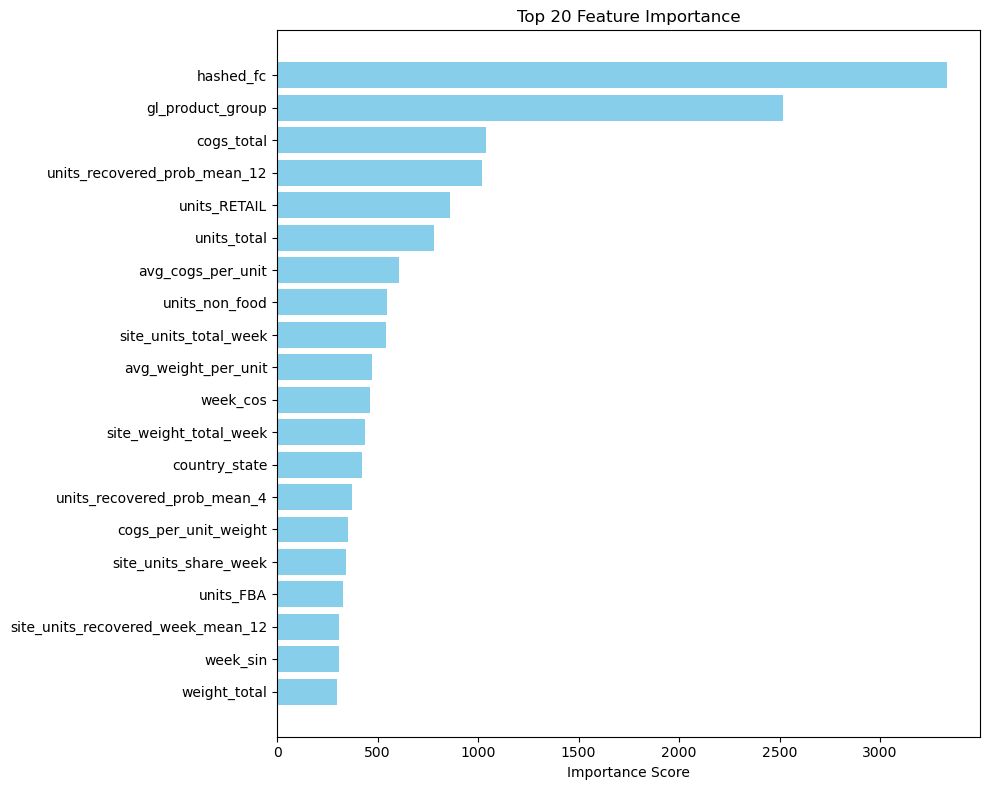

In [30]:
current_inventory_importance = model_prob_current.get_booster().get_score(importance_type='weight')

current_inventory_importance_df = pd.DataFrame({
    'Feature': list(current_inventory_importance.keys()),
    'Importance': list(current_inventory_importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    current_inventory_importance_df['Feature'].head(top_n)[::-1],
    current_inventory_importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

### Without Current Inventory

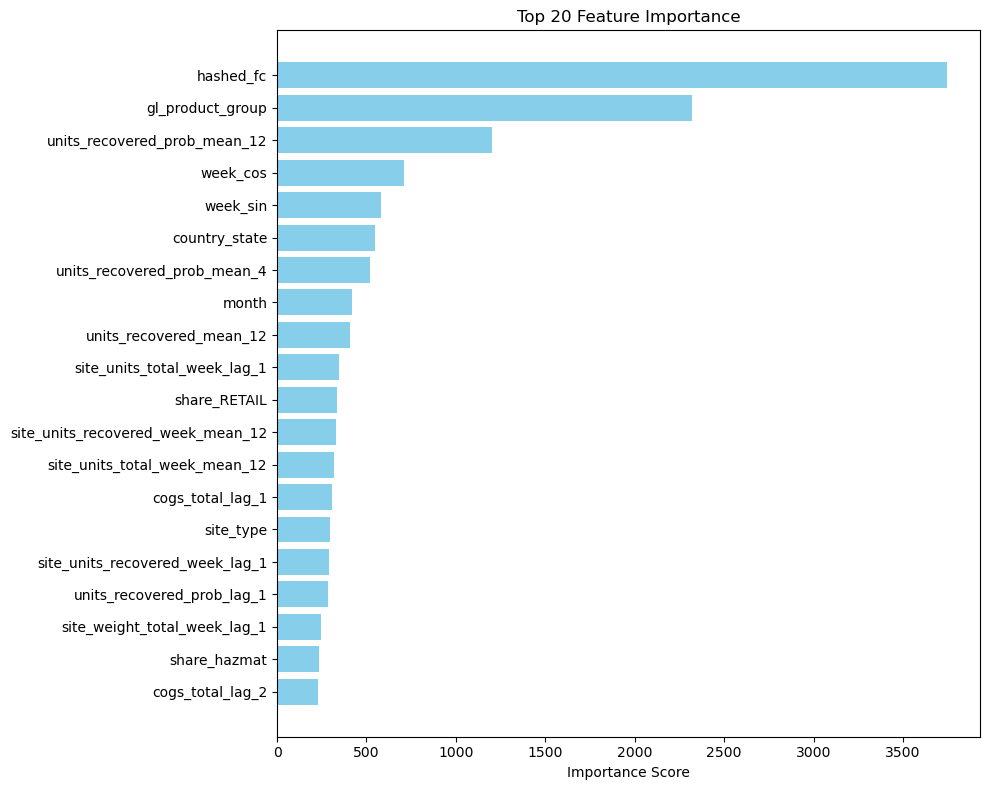

In [32]:
no_current_inventory_importance = model_prob_lag.get_booster().get_score(importance_type='weight')

no_current_inventory_importance_df = pd.DataFrame({
    'Feature': list(no_current_inventory_importance.keys()),
    'Importance': list(no_current_inventory_importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    no_current_inventory_importance_df['Feature'].head(top_n)[::-1],
    no_current_inventory_importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

## Train on logit transformed proportion

In [14]:
EPS = 1e-6  # boundary guard

def logit(p: np.ndarray) -> np.ndarray:
    """Map probability [0, 1] → real line (-inf, +inf)."""
    p = np.clip(p, EPS, 1 - EPS)
    return np.log(p / (1 - p))

def sigmoid(x: np.ndarray) -> np.ndarray:
    """Inverse logit: map real line → probability [0, 1]."""
    return 1 / (1 + np.exp(-x))

In [25]:
# Custom early-stopping eval metric
def prob_mae(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """
    Custom eval metric for XGBRegressor (sklearn API).
    Must return a plain float — XGBoost uses the function name as the metric label.
    Both y_pred and y_true are in logit space — back-transform before computing MAE.
    """
    p_true = sigmoid(y_true)
    p_pred = sigmoid(y_pred)
    return float(np.mean(np.abs(p_pred - p_true)))

In [26]:
# ── categorical columns that need dtype casting ──────────────────────────────
CAT_COLS = [
    'hashed_fc',
    'gl_product_group',
    'country',
    'country_state',
    'site_type',
    'site_category',
]

# ── helper: cast categoricals in-place ───────────────────────────────────────
def cast_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].astype("category")
    return df


# ── main training loop ───────────────────────────────────────────────────────
def run_fold(
    df: pl.DataFrame,
    folds: list,
    features: list,
    target_col: str = "units_recovered_prob",
    n_estimators: int = 2000,       # set high — early stopping will cut it
    early_stopping_rounds: int = 50,
    verbose_eval: int = 100,        # print eval every N rounds; set False to silence
) -> list[dict]:

    results = []

    for i, (train_weeks, val_weeks) in enumerate(folds):

        train_df = df.filter(pl.col("week_date").is_in(train_weeks))
        val_df   = df.filter(pl.col("week_date").is_in(val_weeks))

        X_train = cast_categoricals(train_df.select(features).to_pandas())
        X_val   = cast_categoricals(val_df.select(features).to_pandas())

        y_train = train_df[target_col].to_pandas().values
        y_val   = val_df[target_col].to_pandas().values

        # Skip degenerate folds (all-zero target means no signal)
        if y_train.mean() == 0:
            print(f"  Fold {i+1}: skipped (all-zero target)")
            continue

        # ── logit-transform the target ────────────────────────────────────
        y_train_logit = logit(y_train)
        y_val_logit   = logit(y_val)

        # ── fit model ────────────────────────────────────────────────────
        model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=n_estimators,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            enable_categorical=True,
            random_state=42,
            early_stopping_rounds=early_stopping_rounds,
            eval_metric=prob_mae,              # ← constructor, not fit()
        )

        model.fit(
            X_train, y_train_logit,
            eval_set=[(X_val, y_val_logit)],
            verbose=verbose_eval,
        )

        # ── predict & back-transform ──────────────────────────────────────
        preds_logit = model.predict(X_val)
        preds       = sigmoid(preds_logit)
        preds       = np.clip(preds, 0.0, 1.0)  # safety clip for edge cases

        # ── metrics (all on probability scale) ───────────────────────────
        mae  = mean_absolute_error(y_val, preds)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        r2   = r2_score(y_val, preds)

        best_iter = model.best_iteration
        print(
            f"  Fold {i+1}: MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}"
            f"  best_iter={best_iter}"
        )

        results.append({
            "fold": i + 1,
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
            "best_iteration": best_iter,
            "n_train": len(train_df),
            "n_val": len(val_df),
            "model": model,  # keep for feature importance / SHAP later
        })

    return results

In [27]:
start = time.perf_counter()

print("=== With current inventory features ===")
results_current = run_fold(df, folds, features_with_current_inventory)

print("\n=== With lag-only features ===")
results_lag = run_fold(df, folds, features_with_lag_only)

elapsed = (time.perf_counter() - start) / 60
print(f"\nTotal time: {elapsed:.1f} min")

=== With current inventory features ===


/tmp/ipykernel_1836/3537816778.py:34: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_1836/3537816778.py:35: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  val_df   = df.filter(pl.col("week_date").is_in(val_weeks))


[0]	validation_0-rmse:7.44053	validation_0-prob_mae:0.09538
[100]	validation_0-rmse:4.14015	validation_0-prob_mae:0.03745
[123]	validation_0-rmse:4.17543	validation_0-prob_mae:0.03893
  Fold 1: MAE=0.1732  RMSE=0.3845  R²=-1.3268  best_iter=74


/tmp/ipykernel_1836/3537816778.py:34: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_1836/3537816778.py:35: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  val_df   = df.filter(pl.col("week_date").is_in(val_weeks))


[0]	validation_0-rmse:7.22930	validation_0-prob_mae:0.08746
[100]	validation_0-rmse:3.61458	validation_0-prob_mae:0.03173
[146]	validation_0-rmse:3.62193	validation_0-prob_mae:0.03185
  Fold 2: MAE=0.1090  RMSE=0.2976  R²=-0.5457  best_iter=97


...

[0]	validation_0-rmse:7.48612	validation_0-prob_mae:0.09540
[100]	validation_0-rmse:4.38114	validation_0-prob_mae:0.04061
[118]	validation_0-rmse:4.39670	validation_0-prob_mae:0.04108
  Fold 1: MAE=0.2102  RMSE=0.4268  R²=-1.8674  best_iter=69


/tmp/ipykernel_1836/3537816778.py:34: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_1836/3537816778.py:35: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  val_df   = df.filter(pl.col("week_date").is_in(val_weeks))


[0]	validation_0-rmse:7.25342	validation_0-prob_mae:0.08747
[100]	validation_0-rmse:3.89593	validation_0-prob_mae:0.03417
[147]	validation_0-rmse:3.93940	validation_0-prob_mae:0.03469
  Fold 2: MAE=0.1388  RMSE=0.3437  R²=-1.0610  best_iter=97


/tmp/ipykernel_1836/3537816778.py:34: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("week_date").is_in(train_weeks))
/tmp/ipykernel_1836/3537816778.py:35: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  val_df   = df.filter(pl.col("week_date").is_in(val_weeks))


[0]	validation_0-rmse:7.21690	validation_0-prob_mae:0.08827
[100]	validation_0-rmse:4.20885	validation_0-prob_mae:0.04014
[111]	validation_0-rmse:4.24186	validation_0-prob_mae:0.04024
  Fold 3: MAE=0.0395  RMSE=0.1333  R²=0.6869  best_iter=61

Total time: 22.8 min


In [30]:
def summarize_results(results: list[dict], label: str) -> pl.DataFrame:
    rows = [
        {
            "feature_set": label,
            "fold": str(r["fold"]),
            "mae": round(r["mae"], 4),
            "rmse": round(r["rmse"], 4),
            "r2": round(r["r2"], 4),
            "best_iter": r["best_iteration"],
            "n_train": r["n_train"],
            "n_val": r["n_val"],
        }
        for r in results
    ]

    df = pl.DataFrame(rows)

    mean_row = pl.DataFrame([{
        "feature_set": label,
        "fold": "mean",
        "mae": round(df["mae"].mean(), 4),
        "rmse": round(df["rmse"].mean(), 4),
        "r2": round(df["r2"].mean(), 4),
        "best_iter": int(round(df["best_iter"].mean())),  # ← cast to int
        "n_train": 0,
        "n_val": 0,
    }])

    return pl.concat([df, mean_row])

In [31]:
summary = pl.concat([
    summarize_results(results_current, "current_inventory"),
    summarize_results(results_lag,     "lag_only"),
])

print(summary)

shape: (8, 8)
┌───────────────────┬──────┬────────┬────────┬─────────┬───────────┬─────────┬─────────┐
│ feature_set       ┆ fold ┆ mae    ┆ rmse   ┆ r2      ┆ best_iter ┆ n_train ┆ n_val   │
│ ---               ┆ ---  ┆ ---    ┆ ---    ┆ ---     ┆ ---       ┆ ---     ┆ ---     │
│ str               ┆ str  ┆ f64    ┆ f64    ┆ f64     ┆ i64       ┆ i64     ┆ i64     │
╞═══════════════════╪══════╪════════╪════════╪═════════╪═══════════╪═════════╪═════════╡
│ current_inventory ┆ 1    ┆ 0.1732 ┆ 0.3845 ┆ -1.3268 ┆ 74        ┆ 1618729 ┆ 1871218 │
│ current_inventory ┆ 2    ┆ 0.109  ┆ 0.2976 ┆ -0.5457 ┆ 97        ┆ 3489947 ┆ 2144587 │
│ current_inventory ┆ 3    ┆ 0.0351 ┆ 0.1279 ┆ 0.7119  ┆ 92        ┆ 5634534 ┆ 2374305 │
│ current_inventory ┆ mean ┆ 0.1058 ┆ 0.27   ┆ -0.3869 ┆ 88        ┆ 0       ┆ 0       │
│ lag_only          ┆ 1    ┆ 0.2102 ┆ 0.4268 ┆ -1.8674 ┆ 69        ┆ 1618729 ┆ 1871218 │
│ lag_only          ┆ 2    ┆ 0.1388 ┆ 0.3437 ┆ -1.061  ┆ 97        ┆ 3489947 ┆ 2144587 │
│ lag_o

## Plot Example Prediction

In [33]:
# Make prediction on last 2 week of December 2025
df_example = df.filter((pl.col('year') == 2025) & (pl.col('month') == 12))

X_example = df_example.select(features_with_current_inventory).to_pandas()

# Enforce category type
cat_cols = [
'hashed_fc',
'gl_product_group',
'country',
'country_state',
'site_type',
'site_category'
]

for col in cat_cols:
    X_example[col] = X_example[col].astype("category")

y_example = df_example['units_recovered_prob'].to_pandas()

example_preds = model_prob_current.predict(X_example)

In [34]:
df_example = df_example.with_columns(units_recovered_prob_pred = example_preds)

In [35]:
df_example['hashed_fc'].value_counts().sort(by='count', descending=True)['hashed_fc'][0]

'af3d995c50e41e1251f2fd27dd4e1b9824dbafd1548c97fc59755b02f13b158b'

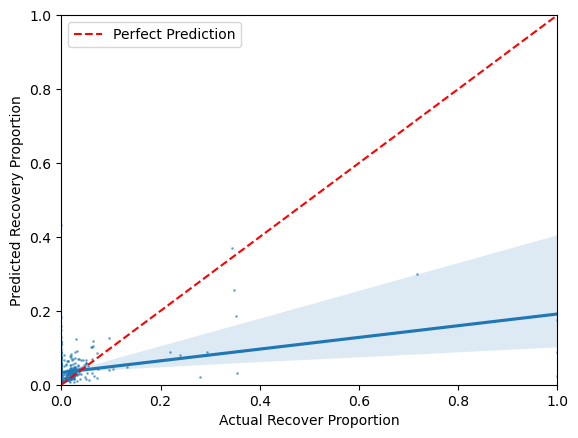

In [36]:
sns.regplot(
    df_example.filter(pl.col('hashed_fc') == 'af3d995c50e41e1251f2fd27dd4e1b9824dbafd1548c97fc59755b02f13b158b'), 
    x='units_recovered_prob', 
    y='units_recovered_prob_pred', 
    scatter_kws={'s': 1, 'alpha': 0.5}
)

# Add the y=x line
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect Prediction')

# Labels and limits
plt.ylabel('Predicted Recovery Proportion')
plt.xlabel('Actual Recover Proportion') 
plt.xlim([0, 1])
plt.ylim([0, 1])

# Optional: add a legend to identify the lines
plt.legend()
plt.show()

In [37]:
import shap

In [38]:
explainer = shap.TreeExplainer(model_prob_current)
shap_values = explainer(X_example)

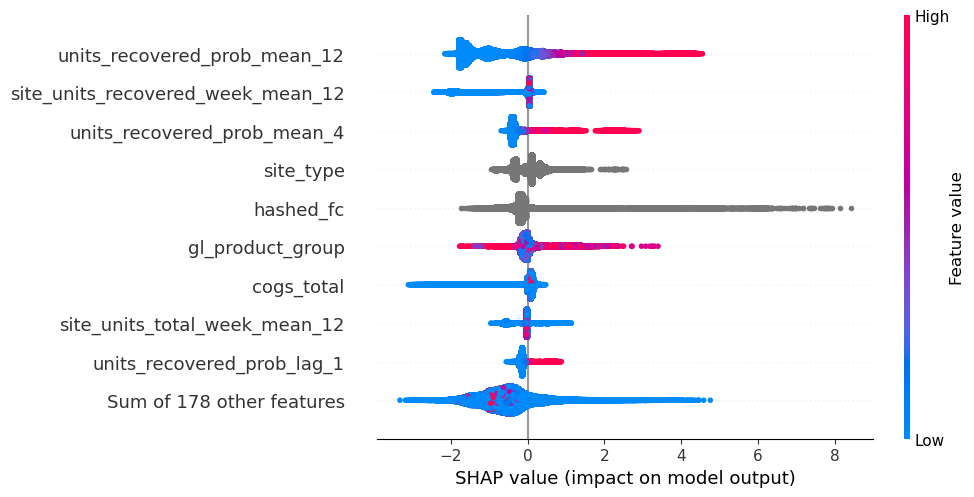

In [39]:
shap.plots.beeswarm(shap_values)

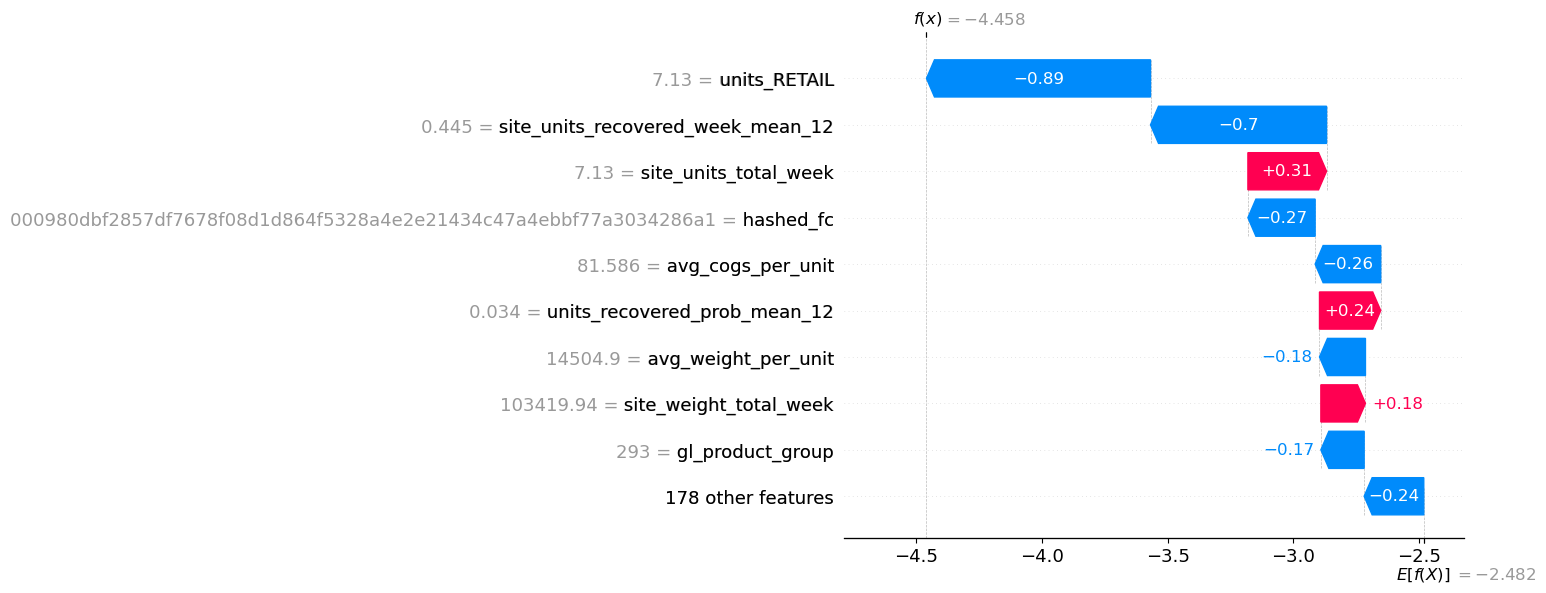

In [40]:
shap.plots.waterfall(shap_values[0])